__WORK 1 : VANILLA LIKELIHOOD METHOD WITH ROLLING VARIANCE__

$σ_t$ = $\sqrt{(Var(local window)}$

Uses nearby data directly.

Signal contaminates the estimate.

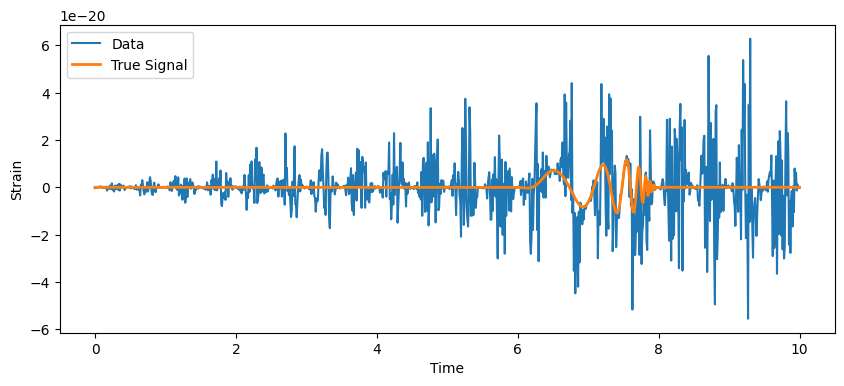

Running MCMC...


100%|████████████████████████████████████| 15000/15000 [01:40<00:00, 149.89it/s]


Done
Number of posterior samples = 32000

Estimated Parameters

A  = 2.5321780448055446e-21 + 4.106946892608237e-22 - 4.16014100337544e-22
cr = 19.752126686339913 + 0.148778049382166 - 0.1453455327539679
tc = 7.988501290269566 + 0.012661427280779236 - 0.014594501168338603


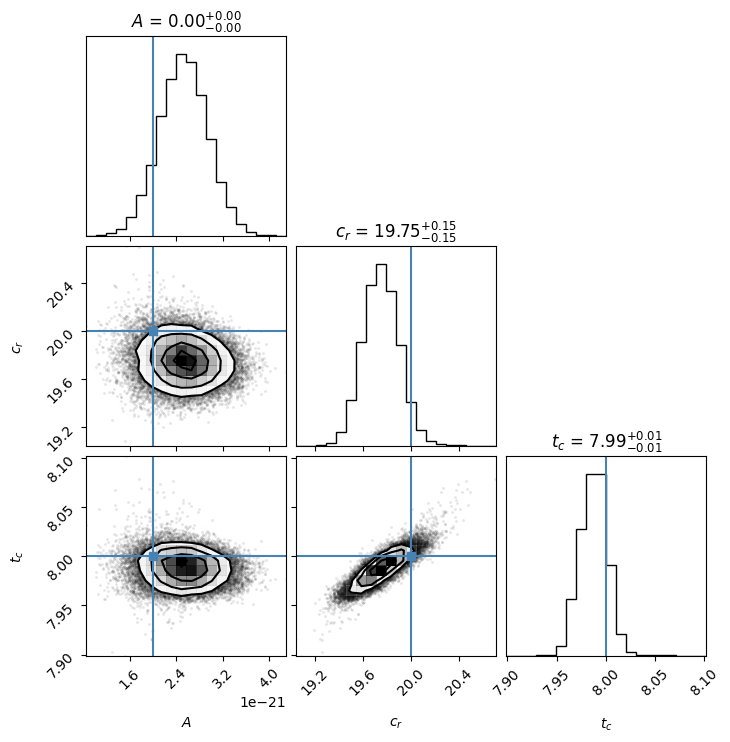

SNR= 5.015560400963909


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
import emcee
import corner

# =====================================================
# Generate Data
# =====================================================

N = 1000
t = np.linspace(0, 10, N)

# True parameters
A_true = 2e-21
cr_true = 20.0
tc_true = 8.0

# Chirp model
def generate_chirp(t, A, cr, tc, apply_window=True):
    h = np.zeros_like(t)
    valid = (t < tc) & (t > (tc - 2.0))
    if not np.any(valid):
        return h
    tau = tc - t[valid]
    phase = -2.0 * cr * (tau + 1e-5)**(-0.25)
    amplitude = A * (cr / (tau + 0.1))**0.5
    signal = amplitude * np.sin(phase)
    if apply_window:
        window = tukey(len(signal), alpha=0.5)
        signal *= window
    h[valid] = signal
    return h

h_true = generate_chirp(t,A_true,cr_true,tc_true)

# Add noise
sigma_true = 2e-22*(1 + 15*t*np.sin(2*np.pi*t)**2)
noise = np.random.normal(0, 1, N) * sigma_true

data = h_true + noise

window = 50
rolling_var = np.zeros(N)
for i in range(N):
    start = max(0, i - window//2)
    stop  = min(N, i + window//2)
    rolling_var[i] = np.var(data[start:stop])
sigma_t = np.sqrt(rolling_var)
sigma_t[sigma_t < 1e-25] = 1e-25

# =====================================================
# Plot Data
# =====================================================

plt.figure(figsize=(10,4))
plt.plot(t, data, label="Data")
plt.plot(t, h_true, lw=2, label="True Signal")
plt.xlabel("Time")
plt.ylabel("Strain")
plt.legend()
plt.show()

# =====================================================
# Log Prior
# =====================================================

def log_prior(theta):
    A, cr, tc = theta
    if (0 < A < 5e-21 and
        0 < cr < 40 and
        0 < tc < 10):
        return 0.0
    return -np.inf

# =====================================================
# Log Likelihood
# =====================================================

def log_likelihood(theta, t, data, sigma_t):
    A, cr, tc = theta
    model = generate_chirp(t, A, cr, tc)
    chi2 = np.sum((data - model)**2 / sigma_t**2)
    return -0.5 * chi2

# =====================================================
# Log Posterior 
# =====================================================

def log_probability(theta, t, data, sigma_t):  
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, data, sigma_t)  #Bayes' theorem in logarithmic form :lnp(θ∣d)=lnp(θ)+lnp(d∣θ)

# =====================================================
# Initial Walker Positions
# =====================================================

ndim = 3
nwalkers = 64

initial = np.array([1.8e-21,18.0,7.5])
pos = initial + 1e-3*np.abs(initial)*np.random.randn(nwalkers, ndim)

# =====================================================
# Run MCMC
# =====================================================

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_probability,args=(t, data, sigma_t))
print("Running MCMC...")
sampler.run_mcmc(pos, 15000, progress=True)
print("Done")

# =====================================================
# Remove Burn-in
# =====================================================

flat_samples = sampler.get_chain(discard=5000,thin=20,flat=True)
print("Number of posterior samples =", len(flat_samples))

# =====================================================
# Parameter Estimates
# =====================================================

A_mcmc = np.percentile(flat_samples[:,0], [16,50,84])
cr_mcmc = np.percentile(flat_samples[:,1], [16,50,84])
tc_mcmc = np.percentile(flat_samples[:,2], [16,50,84])

print("\nEstimated Parameters\n")
print("A  =", A_mcmc[1], "+", A_mcmc[2]-A_mcmc[1], "-", A_mcmc[1]-A_mcmc[0])
print("cr =", cr_mcmc[1], "+", cr_mcmc[2]-cr_mcmc[1], "-", cr_mcmc[1]-cr_mcmc[0])
print("tc =", tc_mcmc[1], "+", tc_mcmc[2]-tc_mcmc[1], "-", tc_mcmc[1]-tc_mcmc[0])

# =====================================================
# Corner Plot
# =====================================================

figure = corner.corner(flat_samples,labels=[r"$A$",r"$c_r$",r"$t_c$"],truths=[A_true,cr_true,tc_true],show_titles=True)
plt.show()

rho=np.sqrt(np.sum(h_true**2/sigma_t**2))
print("SNR=",rho)

__WORK 2 : GARCH LIKELIHOOD METHOD__

1. Fit Region 1 only.
2. Obtain $ω$ , $α$ , $β$.
3. Forecast variance recursively.

$σ_t^2$ = $ω$ + $α$ $ϵ_t−1^2$ + $β$ $σ_t−1^2$

Signal region is not used to fit the parameters.


Estimated GARCH Parameters
omega = 0.5872282071094586
alpha = 0.4642333746357995
beta  = 0.5357666311718442


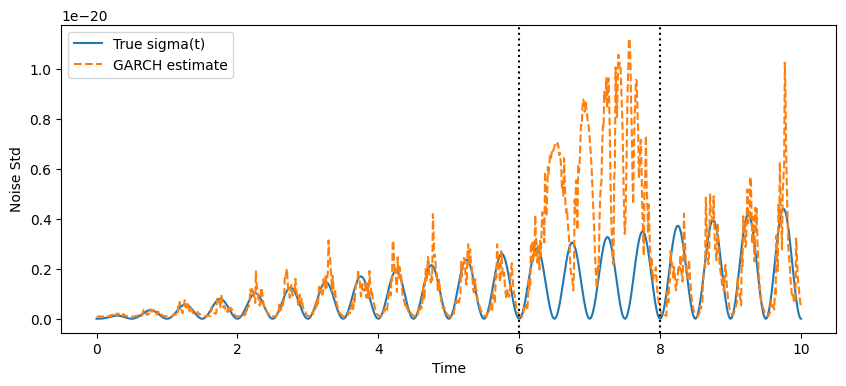

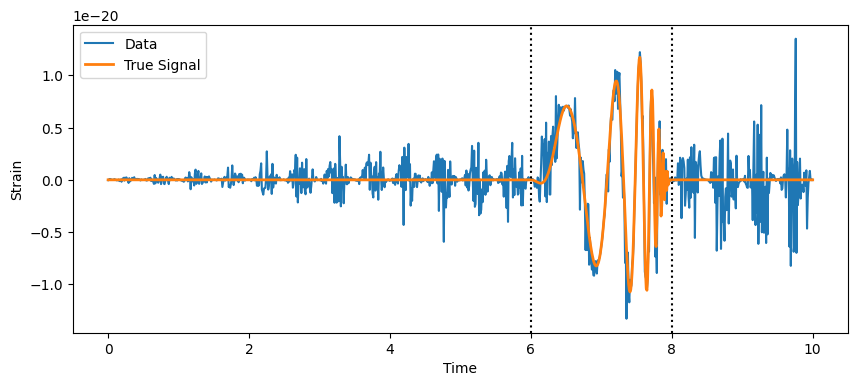

Running MCMC...


100%|████████████████████████████████████| 15000/15000 [01:37<00:00, 153.80it/s]


Done
Number of posterior samples = 32000

Estimated Parameters

A  = 1.9295320965320254e-21 + 2.5299181110608546e-22 - 2.8794842119445973e-22
cr = 16.434555147830658 + 3.557045167546498 - 0.09543353622046524
tc = 7.915121270188062 + 0.08471462955062314 - 0.025514906749806165


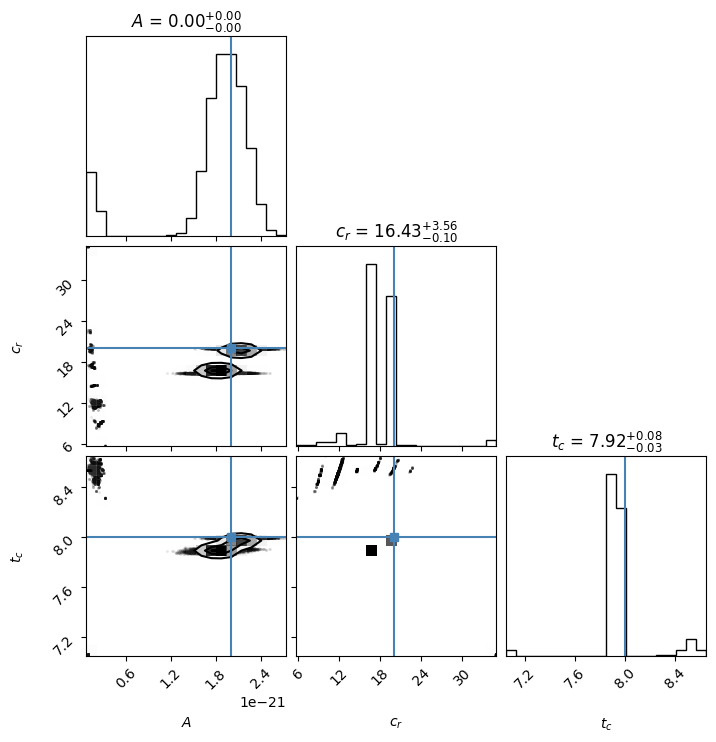


SNR = 12.84871913572189


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from arch import arch_model
import emcee
import corner

# =====================================================
# Generate Data
# =====================================================

N = 1000
t = np.linspace(0, 10, N)

# True parameters
A_true = 2e-21
cr_true = 20.0
tc_true = 8.0

# =====================================================
# Chirp Model
# =====================================================

def generate_chirp(t, A, cr, tc, apply_window=True):
    h = np.zeros_like(t)
    valid = (t < tc) & (t > (tc - 2.0))
    if not np.any(valid):
        return h
    tau = tc - t[valid]
    phase = -2.0 * cr * (tau + 1e-5)**(-0.25)
    amplitude = A * (cr / (tau + 0.1))**0.5
    signal = amplitude * np.sin(phase)
    if apply_window:
        signal *= tukey(len(signal), alpha=0.5)
    h[valid] = signal
    return h

h_true = generate_chirp(t,A_true,cr_true,tc_true)  # Create Signal

sigma_true = 3e-23 * (1 + 15*t*np.sin(2*np.pi*t)**2)  # Non-stationary Noise
noise = np.random.normal(0,sigma_true,N)

data = h_true + noise

# =====================================================
# Region Definitions
# =====================================================

signal_start = tc_true - 2.0   # 6
signal_end   = tc_true         # 8

background_mask = t < signal_start  # Noise only region

# =====================================================
# Fit GARCH to Region 1 only
# =====================================================

background_data = data[background_mask]

scale = 1e22 
background_scaled = background_data * scale

garch = arch_model(background_scaled,mean="Zero",vol="GARCH",p=1,q=1)
result = garch.fit(disp="off")

omega = result.params["omega"]
alpha = result.params["alpha[1]"]
beta  = result.params["beta[1]"]

print("\nEstimated GARCH Parameters")
print("omega =", omega)
print("alpha =", alpha)
print("beta  =", beta)

# Conditional variance in Region 1
sigma2_bg = result.conditional_volatility**2

# =====================================================
# Forecast Variance Into Region 2
# =====================================================

sigma2_full = np.zeros(N)
n_bg = len(background_scaled)
sigma2_full[:n_bg] = sigma2_bg
data_scaled = data * scale
for i in range(n_bg, N):
    eps_prev = data_scaled[i - 1]
    sigma2_full[i] = (omega + alpha * eps_prev**2 + beta * sigma2_full[i - 1])

# Convert back to physical units
sigma2_full /= scale**2
sigma2_full[sigma2_full < 1e-50] = 1e-50
sigma_t = np.sqrt(sigma2_full)

# =====================================================
# Plot Sigma Estimate
# =====================================================

plt.figure(figsize=(10,4))
plt.plot(t, sigma_true, label="True sigma(t)")
plt.plot(t, sigma_t, '--', label="GARCH estimate")
plt.axvline(signal_start, color='k', ls=':')
plt.axvline(signal_end, color='k', ls=':')
plt.xlabel("Time")
plt.ylabel("Noise Std")
plt.legend()
plt.show()

# =====================================================
# Plot Data
# =====================================================

plt.figure(figsize=(10,4))
plt.plot(t, data, label="Data")
plt.plot(t, h_true, lw=2, label="True Signal")
plt.axvline(signal_start, color='k', ls=':')
plt.axvline(signal_end, color='k', ls=':')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Strain")
plt.show()

# =====================================================
# Prior
# =====================================================

def log_prior(theta):
    A, cr, tc = theta
    if (
        0 < A < 5e-21
        and 0 < cr < 40
        and 0 < tc < 10
    ):
        return 0.0
    return -np.inf

# =====================================================
# Likelihood
# =====================================================

def log_likelihood(theta, t, data, sigma_t):
    A, cr, tc = theta
    model = generate_chirp(t,A,cr,tc)
    chi2 = np.sum((data - model)**2 /sigma_t**2)
    return -0.5 * chi2

# =====================================================
# Posterior
# =====================================================

def log_probability(theta, t, data, sigma_t):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta,t,data,sigma_t)

# =====================================================
# Initial Walkers
# =====================================================

ndim = 3
nwalkers = 64

initial = np.array([1.8e-21,18.0,7.5])
pos = (initial + 1e-3*np.abs(initial) * np.random.randn(nwalkers,ndim))

# =====================================================
# Run MCMC
# =====================================================

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_probability,args=(t, data, sigma_t))
print("Running MCMC...")

sampler.run_mcmc(pos,15000,progress=True)
print("Done")

# =====================================================
# Burn-in Removal
# =====================================================

flat_samples = sampler.get_chain(discard=5000,thin=20,flat=True)

print("Number of posterior samples =",len(flat_samples))

# =====================================================
# Parameter Estimates
# =====================================================

A_mcmc = np.percentile(flat_samples[:,0],[16,50,84])
cr_mcmc = np.percentile(flat_samples[:,1],[16,50,84])
tc_mcmc = np.percentile(flat_samples[:,2],[16,50,84])

print("\nEstimated Parameters\n")
print("A  =",A_mcmc[1],"+",A_mcmc[2]-A_mcmc[1],"-",A_mcmc[1]-A_mcmc[0])
print("cr =",cr_mcmc[1],"+",cr_mcmc[2]-cr_mcmc[1],"-",cr_mcmc[1]-cr_mcmc[0])
print("tc =",tc_mcmc[1],"+",tc_mcmc[2]-tc_mcmc[1],"-",tc_mcmc[1]-tc_mcmc[0])

# =====================================================
# Corner Plot
# =====================================================

corner.corner(flat_samples,labels=[r"$A$",r"$c_r$",r"$t_c$"],truths=[A_true,cr_true,tc_true],show_titles=True)
plt.show()

# =====================================================
# SNR
# =====================================================

rho = np.sqrt(np.sum(h_true**2 /sigma_t**2))
print("\nSNR =", rho)






__WORK 2 : GARCH LIKELIHOOD METHOD WITH AMPLITUDE FIXED (cr,tc)__




/home/user/anaconda3/envs/pycbc311/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.867e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)



Estimated GARCH Parameters
omega = 12.179417878873608
alpha = 0.3155795136539847
beta  = 0.6844204864375631


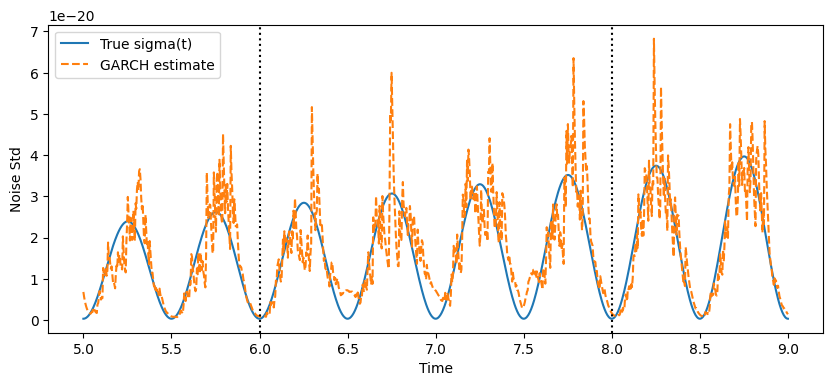

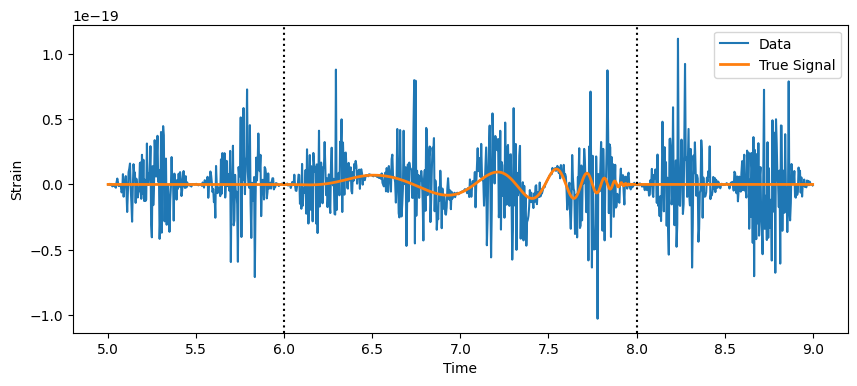

Running MCMC...


100%|█████████████████████████████████████| 15000/15000 [02:44<00:00, 91.40it/s]


Done
Number of posterior samples = 32000

Estimated Parameters

cr = 19.04530067332653 + 0.027812610060678367 - 0.027926789919664685
tc = 7.496619469638244 + 0.00584464067161683 - 0.006122907084446183


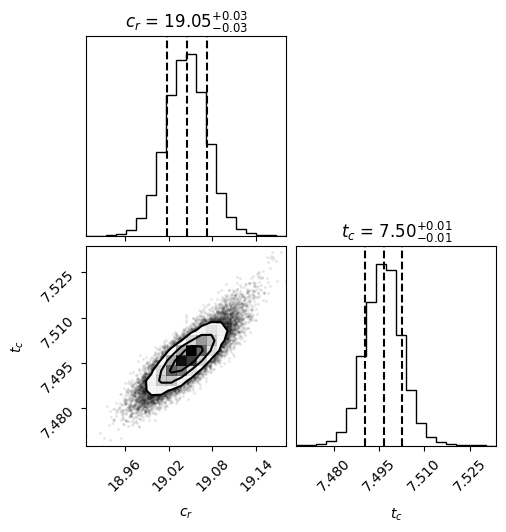


SNR = 11.440722266374157


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from arch import arch_model
import emcee
import corner

# =====================================================
# Generate Data
# =====================================================

N = 1000
t = np.linspace(5, 9, N)

# True parameters
A_true = 2e-21
cr_true = 20.0
tc_true = 8.0

# =====================================================
# Chirp Model
# =====================================================

def generate_chirp(t, A, cr, tc, apply_window=True):
    h = np.zeros_like(t)
    valid = (t < tc) & (t > (tc - 2.0))
    if not np.any(valid):
        return h
    tau = tc - t[valid]
    phase = -2.0 * cr * (tau + 1e-5)**(-0.25)
    amplitude = A * (cr / (tau + 0.1))**0.5
    signal = amplitude * np.sin(phase)
    if apply_window:
        signal *= tukey(len(signal), alpha=0.5)
    h[valid] = signal
    return h

h_true = generate_chirp(t,A_true,cr_true,tc_true)  # Create Signal

sigma_true = 3e-22 * (1 + 15*t*np.sin(2*np.pi*t)**2)  # Non-stationary Noise
noise = np.random.normal(0,sigma_true,N)

data = h_true + noise

# =====================================================
# Region Definitions
# =====================================================

signal_start = tc_true - 2.0   # 6
signal_end   = tc_true         # 8

background_mask = t < signal_start  # Noise only region

# =====================================================
# Fit GARCH to Region 1 only
# =====================================================

background_data = data[background_mask]

scale = 1e22 
background_scaled = background_data * scale

garch = arch_model(background_scaled,mean="Zero",vol="GARCH",p=1,q=1)
result = garch.fit(disp="off")

omega = result.params["omega"]
alpha = result.params["alpha[1]"]
beta  = result.params["beta[1]"]

print("\nEstimated GARCH Parameters")
print("omega =", omega)
print("alpha =", alpha)
print("beta  =", beta)

# Conditional variance in Region 1
sigma2_bg = result.conditional_volatility**2

# =====================================================
# Forecast Variance Into Region 2
# =====================================================

sigma2_full = np.zeros(N)
n_bg = len(background_scaled)
sigma2_full[:n_bg] = sigma2_bg
data_scaled = data * scale
for i in range(n_bg, N):
    eps_prev = data_scaled[i - 1]
    sigma2_full[i] = (omega + alpha * eps_prev**2 + beta * sigma2_full[i - 1])

# Convert back to physical units
sigma2_full /= scale**2
sigma2_full[sigma2_full < 1e-50] = 1e-50
sigma_t = np.sqrt(sigma2_full)

# =====================================================
# Plot Sigma Estimate
# =====================================================

plt.figure(figsize=(10,4))
plt.plot(t, sigma_true, label="True sigma(t)")
plt.plot(t, sigma_t, '--', label="GARCH estimate")
plt.axvline(signal_start, color='k', ls=':')
plt.axvline(signal_end, color='k', ls=':')
plt.xlabel("Time")
plt.ylabel("Noise Std")
plt.legend()
plt.show()

# =====================================================
# Plot Data
# =====================================================

plt.figure(figsize=(10,4))
plt.plot(t, data, label="Data")
plt.plot(t, h_true, lw=2, label="True Signal")
plt.axvline(signal_start, color='k', ls=':')
plt.axvline(signal_end, color='k', ls=':')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Strain")
plt.show()

# =====================================================
# Prior
# =====================================================

def log_prior(theta):
    cr, tc = theta
    if (
        15 < cr < 25
        and 5 < tc < 10
    ):
        return 0.0
    return -np.inf

# =====================================================
# Likelihood
# =====================================================

def log_likelihood(theta, t, data, sigma_t):
    cr, tc = theta
    model = generate_chirp(t,A_true,cr,tc)
    chi2 = np.sum((data - model)**2 /sigma_t**2)
    return -0.5 * chi2

# =====================================================
# Posterior
# =====================================================

def log_probability(theta, t, data, sigma_t):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta,t,data,sigma_t)

# =====================================================
# Initial Walkers
# =====================================================

ndim = 2
nwalkers = 64

initial = np.array([19.0,7.5])
pos = (initial + 1e-3*np.abs(initial) * np.random.randn(nwalkers,ndim))

# =====================================================
# Run MCMC
# =====================================================

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_probability,args=(t, data, sigma_t))
print("Running MCMC...")

sampler.run_mcmc(pos,15000,progress=True)
print("Done")

# =====================================================
# Burn-in Removal
# =====================================================

flat_samples = sampler.get_chain(discard=5000,thin=20,flat=True)

print("Number of posterior samples =",len(flat_samples))

# =====================================================
# Parameter Estimates
# =====================================================

cr_mcmc = np.percentile(flat_samples[:,0],[16,50,84])
tc_mcmc = np.percentile(flat_samples[:,1],[16,50,84])

print("\nEstimated Parameters\n")
print("cr =",cr_mcmc[1],"+",cr_mcmc[2]-cr_mcmc[1],"-",cr_mcmc[1]-cr_mcmc[0])
print("tc =",tc_mcmc[1],"+",tc_mcmc[2]-tc_mcmc[1],"-",tc_mcmc[1]-tc_mcmc[0])

# =====================================================
# Corner Plot
# =====================================================

corner.corner(flat_samples,labels=[r"$c_r$",r"$t_c$"],truths=[cr_true,tc_true],show_titles=True,quantiles=[0.16, 0.5, 0.84],
    title_quantiles=[0.16, 0.5, 0.84])
plt.show()

# =====================================================
# SNR
# =====================================================

rho = np.sqrt(np.sum(h_true**2 /sigma_t**2))
print("\nSNR =", rho)

__WORK 3 : METHOD 1 (JOINT GARCH)__

1. sample (cr,tc,omega,alpha,beta) all together
2. at every mcmc step:
   1. propose (cr,tc,omega,alpha,beta)
   2. build chirp h(cr,tc)
   3. compute residuals
   4. run garch recursion
   5. compute likelihood from residuals and sigma_t
   6. repeat 1000s of times
3. we get posterior for (cr,tc,omega,alpha,beta)
4. plot:
   1. corner plot
   2. sigma vs true sigma plot
   3. data + signal + glitch plot

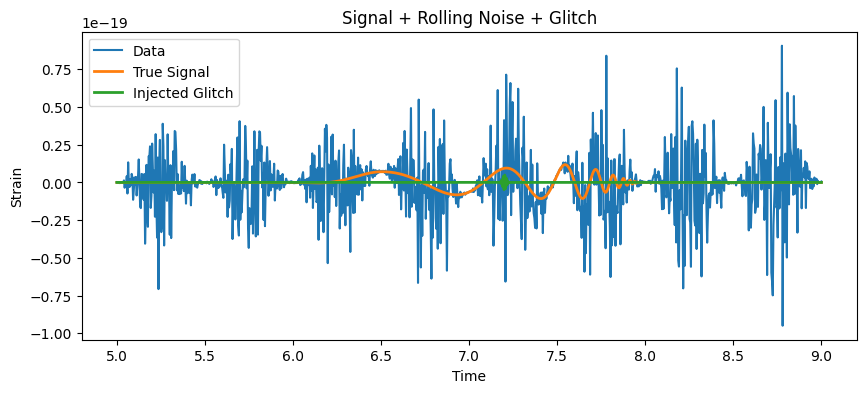

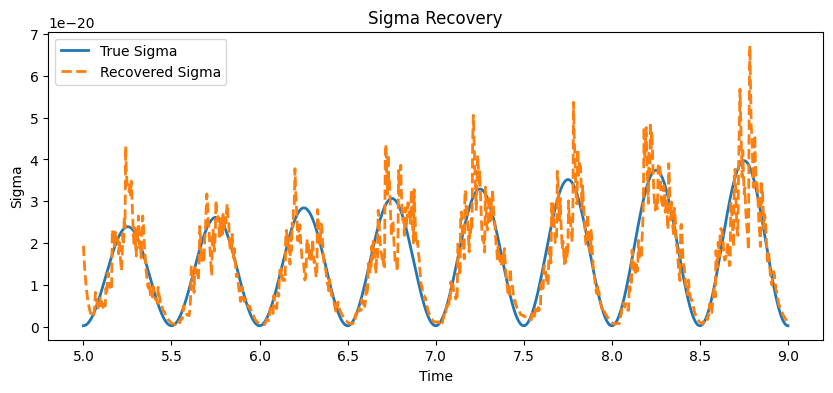

Running MCMC...


100%|█████████████████████████████████████| 30000/30000 [21:28<00:00, 23.28it/s]


Done
Posterior samples = 256000

Estimated Parameters

cr = 20.023498176115986 + 0.01999922452832692 - 0.02428282250206948
tc = 8.004901404822823 + 0.0020410317663515087 - 0.0030844748561200674


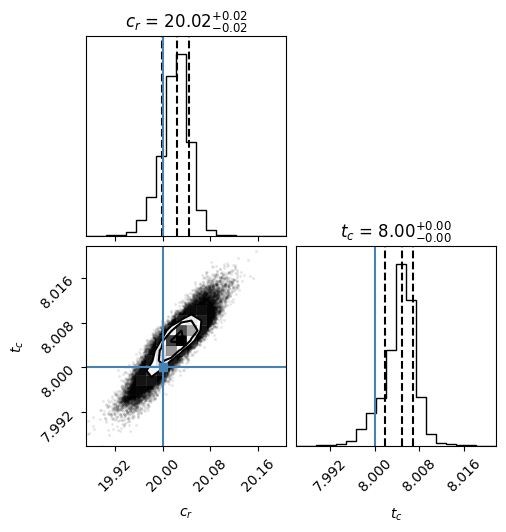

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
import emcee
import corner

# =====================================================
# Generate Data
# =====================================================

N = 1000
t = np.linspace(5, 9, N)

# -----------------------------------------------------
# True Signal Parameters
# -----------------------------------------------------

A_true  = 2e-21
cr_true = 20.0
tc_true = 8.0

# -----------------------------------------------------
# True GARCH Parameters
# -----------------------------------------------------

omega_true = 0.05
alpha_true = 0.15
beta_true  = 0.80

# =====================================================
# Chirp Model
# =====================================================

def generate_chirp(t, A, cr, tc, apply_window=True):
    h = np.zeros_like(t)
    valid = (t < tc) & (t > tc - 2.0)
    if not np.any(valid):
        return h
    tau = tc - t[valid]
    phase = -2.0 * cr * (tau + 1e-5)**(-0.25)
    amplitude = A * np.sqrt(cr / (tau + 0.1))
    signal = amplitude * np.sin(phase)
    if apply_window:
        signal *= tukey(len(signal), alpha=0.5)
    h[valid] = signal
    return h

# =====================================================
# Generate Rolling-Variance Noise
# =====================================================

sigma_true = 3e-22 * (1 + 15*t*np.sin(2*np.pi*t)**2)
noise = np.random.normal(0, sigma_true)

# =====================================================
# Inject Short High-Amplitude Sine-Gaussian Glitch
# =====================================================

glitch_amp = 5e-21
glitch_t0  = 7.2
glitch_tau = 0.01
glitch_f0  = 120

glitch = (glitch_amp* np.exp(-(t-glitch_t0)**2/(2*glitch_tau**2))* np.sin(2*np.pi*glitch_f0*(t-glitch_t0)))

# =====================================================
# Data
# =====================================================

h_true = generate_chirp(t, A_true, cr_true, tc_true)

data = h_true + noise + glitch

# =====================================================
# Plot Data + Signal + Glitch
# =====================================================

plt.figure(figsize=(10,4))
plt.plot(t,data,label="Data")
plt.plot(t,h_true,label="True Signal",lw=2)
plt.plot(t,glitch,label="Injected Glitch",lw=2)
plt.xlabel("Time")
plt.ylabel("Strain")
plt.legend()
plt.title("Signal + Rolling Noise + Glitch")
plt.show()

# =====================================================
# GARCH Recursion
# =====================================================

scale = 1e22

def garch_sigma(residual, omega, alpha, beta):
    r = residual * scale
    N = len(r)
    sigma2 = np.zeros(N)
    sigma2[0] = np.var(r)
    for i in range(1, N):
        sigma2[i] = (omega+ alpha * r[i-1]**2+ beta  * sigma2[i-1])
        if sigma2[i] < 1e-12:
            sigma2[i] = 1e-12
    sigma2 /= scale**2
    return np.sqrt(sigma2)

# =====================================================
# Prior
# =====================================================

def log_prior(theta):
    cr, tc, omega, alpha, beta = theta
    if not (18 < cr < 22):
        return -np.inf
    if not (7.5 < tc < 8.5):
        return -np.inf
    if not (1e-5 < omega < 5):
        return -np.inf
    if not (0 < alpha < 1):
        return -np.inf
    if not (0 < beta < 1):
        return -np.inf
    if alpha + beta >= 0.999:
        return -np.inf
    return 0.0

# =====================================================
# Joint Signal + GARCH Likelihood
# =====================================================

def log_likelihood(theta, t, data):
    cr, tc, omega, alpha, beta = theta
    model = generate_chirp(t,A_true,cr,tc)
    residual = data - model
    sigma_t = garch_sigma(residual,omega,alpha,beta)
    sigma2 = sigma_t**2
    lnL = -0.5*np.sum(residual**2/sigma2+ np.log(sigma2))
    return lnL

# =====================================================
# Sigma Recovery Plot
# =====================================================

best = np.median(flat_samples,axis=0)
cr_fit, tc_fit, omega_fit, alpha_fit, beta_fit = best
model_fit = generate_chirp(t,A_true,cr_fit,tc_fit)
residual_fit = data - model_fit
sigma_fit = garch_sigma(residual_fit,omega_fit,alpha_fit,beta_fit)

plt.figure(figsize=(10,4))
plt.plot(t,sigma_true,lw=2,label="True Sigma")
plt.plot(t,sigma_fit,"--",lw=2,label="Recovered Sigma")
plt.xlabel("Time")
plt.ylabel("Sigma")
plt.legend()
plt.title("Sigma Recovery")
plt.show()

# =====================================================
# Posterior
# =====================================================

def log_probability(theta, t, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta,t,data)

# =====================================================
# Initial Walkers
# =====================================================

ndim = 5
nwalkers = 64

initial = np.array([20.0,8,0.05,0.15,0.80])
pos = initial + 1e-4*np.abs(initial)*np.random.randn(nwalkers, ndim)

# =====================================================
# Run MCMC
# =====================================================

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_probability,args=(t,data))

print("Running MCMC...")
sampler.run_mcmc(pos,30000,progress=True)
print("Done")

# =====================================================
# Burn-in Removal
# =====================================================

flat_samples = sampler.get_chain(discard=10000,thin=5,flat=True)

print("Posterior samples =",len(flat_samples))

# =====================================================
# Parameter Estimates
# =====================================================

cr_mcmc = np.percentile(flat_samples[:,0],[16,50,84])
tc_mcmc = np.percentile(flat_samples[:,1],[16,50,84])

print("\nEstimated Parameters\n")
print("cr =",cr_mcmc[1],"+", cr_mcmc[2]-cr_mcmc[1],"-", cr_mcmc[1]-cr_mcmc[0])
print("tc =",tc_mcmc[1],"+", tc_mcmc[2]-tc_mcmc[1],"-", tc_mcmc[1]-tc_mcmc[0])

# =====================================================
# Corner Plot (cr and tc only)
# =====================================================

corner.corner(flat_samples[:, :2],labels=[r"$c_r$",r"$t_c$"],truths=[cr_true,tc_true],show_titles=True,
    quantiles=[0.16, 0.5, 0.84],title_quantiles=[0.16, 0.5, 0.84])
plt.show()


__WORK 3 : METHOD 2 (FIXED GARCH)__

1. Estimate garch paremeters once
2. Fix them
3. Then during MCMC, sample only (cr,tc)
4. At every step
   1. Build chirp
   2. Compute residuals
   3. Run GARCH recursion using fixed GARCH parameters
   4. Compute likelihood
5. Result : posterior only for (cr,tc)

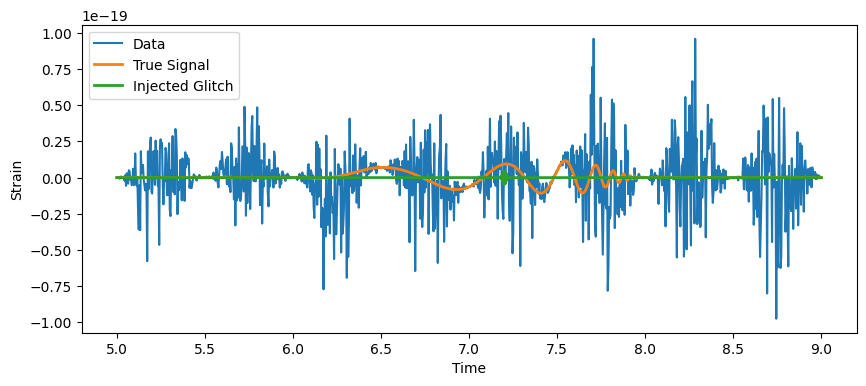

/home/user/anaconda3/envs/pycbc311/lib/python3.11/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.926e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)



Fixed GARCH Parameters
omega = 22.857676349898266
alpha = 0.28619007653899564
beta  = 0.7138099234610041


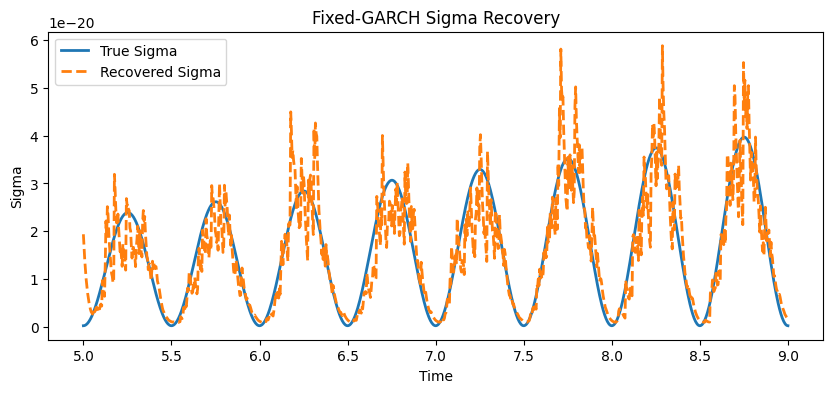


Running MCMC...


100%|█████████████████████████████████████| 30000/30000 [29:41<00:00, 16.84it/s]


Done
Acceptance Fraction = 0.7116270833333334

Estimated Parameters

cr = 20.044278155095206 + 0.03531772829203561 - 0.03309978221365739
tc = 8.00445522265389 + 0.003947798870704844 - 0.0035876068901004032


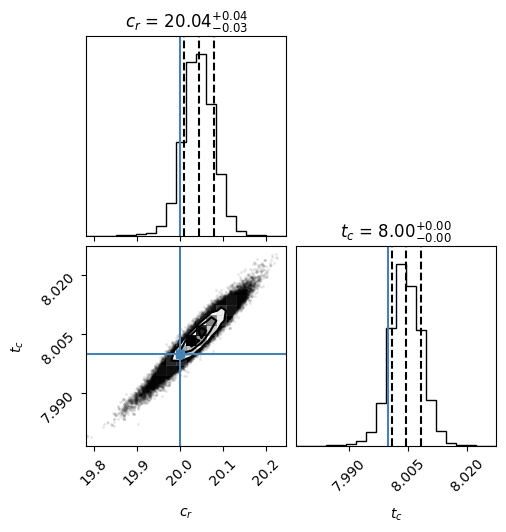

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from arch import arch_model
import emcee
import corner

# =====================================================
# Generate Data
# =====================================================

N = 1000
t = np.linspace(5, 9, N)

A_true = 2e-21
cr_true = 20.0
tc_true = 8.0

# =====================================================
# Chirp Model
# =====================================================

def generate_chirp(t, A, cr, tc, apply_window=True):
    h = np.zeros_like(t)
    valid = (t < tc) & (t > tc - 2.0)
    if not np.any(valid):
        return h
    tau = tc - t[valid]
    phase = -2.0 * cr * (tau + 1e-5)**(-0.25)
    amplitude = A * np.sqrt(cr / (tau + 0.1))
    signal = amplitude * np.sin(phase)
    if apply_window:
        signal *= tukey(len(signal), alpha=0.5)
    h[valid] = signal
    return h

# =====================================================
# Rolling Variance Noise
# =====================================================

sigma_true = 3e-22 * (1 + 15*t*np.sin(2*np.pi*t)**2)

noise = np.random.normal(0, sigma_true)

# =====================================================
# High-Amplitude Sine-Gaussian Glitch
# =====================================================

glitch_amp = 5e-21
glitch_t0  = 7.2
glitch_tau = 0.01
glitch_f0  = 120

glitch = (glitch_amp* np.exp(-(t-glitch_t0)**2/(2*glitch_tau**2))* np.sin(2*np.pi*glitch_f0*(t-glitch_t0)))

# =====================================================
# Data
# =====================================================

h_true = generate_chirp(t,A_true,cr_true,tc_true)

data = h_true + noise + glitch

# =====================================================
# Plot Data
# =====================================================

plt.figure(figsize=(10,4))
plt.plot(t,data,label="Data")
plt.plot(t,h_true,lw=2,label="True Signal")
plt.plot(t,glitch,lw=2,label="Injected Glitch")
plt.xlabel("Time")
plt.ylabel("Strain")
plt.legend()
plt.show()

# =====================================================
# Estimate GARCH Parameters Once
# =====================================================

signal_start = tc_true - 2.0
background_mask = t < signal_start
background_data = data[background_mask]

scale = 1e22
background_scaled = background_data * scale
garch = arch_model(background_scaled,mean="Zero",vol="GARCH",p=1,q=1)
result = garch.fit(disp="off")

omega_fixed = result.params["omega"]
alpha_fixed = result.params["alpha[1]"]
beta_fixed  = result.params["beta[1]"]

print("\nFixed GARCH Parameters")
print("omega =", omega_fixed)
print("alpha =", alpha_fixed)
print("beta  =", beta_fixed)

# =====================================================
# GARCH Recursion
# =====================================================

def garch_sigma(residual,omega,alpha,beta):
    r = residual * scale
    N = len(r)
    sigma2 = np.zeros(N)
    sigma2[0] = np.var(r)
    for i in range(1,N):
        sigma2[i] = (omega+ alpha*r[i-1]**2+ beta*sigma2[i-1])
        if sigma2[i] < 1e-12:
            sigma2[i] = 1e-12
    sigma2 /= scale**2
    return np.sqrt(sigma2)

# =====================================================
# Sigma Recovery Plot
# =====================================================

best = np.median(flat_samples,axis=0)
cr_fit, tc_fit = best
model_fit = generate_chirp(t,A_true,cr_fit,tc_fit)
residual_fit = data - model_fit
sigma_fit = garch_sigma(residual_fit,omega_fixed,alpha_fixed,beta_fixed)

plt.figure(figsize=(10,4))
plt.plot(t,sigma_true,lw=2,label="True Sigma")
plt.plot(t,sigma_fit,"--",lw=2,label="Recovered Sigma")
plt.xlabel("Time")
plt.ylabel("Sigma")
plt.legend()
plt.title("Fixed-GARCH Sigma Recovery")
plt.show()

# =====================================================
# Prior
# =====================================================

def log_prior(theta):
    cr, tc = theta
    if (
        18 < cr < 22
        and
        7.5 < tc < 8.5
    ):
        return 0.0
    return -np.inf

# =====================================================
# Fixed-GARCH Likelihood
# =====================================================

def log_likelihood(theta,t,data):
    cr, tc = theta
    model = generate_chirp(t,A_true,cr,tc)
    residual = data - model
    sigma_t = garch_sigma(residual,omega_fixed,alpha_fixed,beta_fixed)
    sigma2 = sigma_t**2
    lnL = -0.5*np.sum(residual**2/sigma2+ np.log(sigma2))
    return lnL

# =====================================================
# Posterior
# =====================================================

def log_probability(theta,t,data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta,t,data)

# =====================================================
# Initial Walkers
# =====================================================

ndim = 2
nwalkers = 64

initial = np.array([20.0,8.0])
pos = (initial+ 1e-4*np.abs(initial)* np.random.randn(nwalkers,ndim))

# =====================================================
# Run MCMC
# =====================================================

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_probability,args=(t,data))

print("\nRunning MCMC...")
sampler.run_mcmc(pos,30000,progress=True)
print("Done")

print("Acceptance Fraction =",np.mean(sampler.acceptance_fraction))

# =====================================================
# Burn-in Removal
# =====================================================

flat_samples = sampler.get_chain(discard=10000,thin=5,flat=True)

# =====================================================
# Parameter Estimates
# =====================================================

cr_mcmc = np.percentile(flat_samples[:,0],[16,50,84])
tc_mcmc = np.percentile(flat_samples[:,1],[16,50,84])

print("\nEstimated Parameters\n")
print("cr =",cr_mcmc[1],"+",cr_mcmc[2]-cr_mcmc[1],"-",cr_mcmc[1]-cr_mcmc[0])
print("tc =",tc_mcmc[1],"+",tc_mcmc[2]-tc_mcmc[1],"-",tc_mcmc[1]-tc_mcmc[0])

# =====================================================
# Corner Plot
# =====================================================

corner.corner(flat_samples,labels=[r"$c_r$",r"$t_c$"],truths=[cr_true,tc_true],show_titles=True,quantiles=[0.16,0.5,0.84],
    title_quantiles=[0.16,0.5,0.84])
plt.show()


__WORK 4 (A) : COLOURED NOISE - FIXED GARCH__


1. Generate chirp signal.
2. Generate rolling colored noise.
3. Inject a sine-Gaussian glitch.
4. Construct data
5. Estimate GARCH(1,1) parameters from the background region.
6. Fix the estimated GARCH parameters.
7. Sample only (cr,tc)
8. At each MCMC step:
   - Generate chirp.
   - Compute residuals.
   - Compute sigma_t using fixed GARCH parameters.
   - Evaluate likelihood.
9. Plots

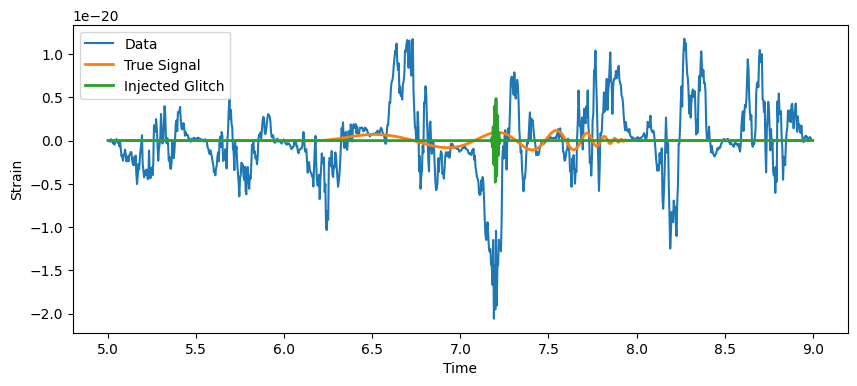


Fixed GARCH Parameters
omega = 1.7564230518088597
alpha = 0.4867435908890888
beta  = 0.5132564090910351

Running MCMC...


100%|█████████████████████████████████████| 30000/30000 [40:32<00:00, 12.33it/s]


Done
Acceptance Fraction = 0.6618104166666667


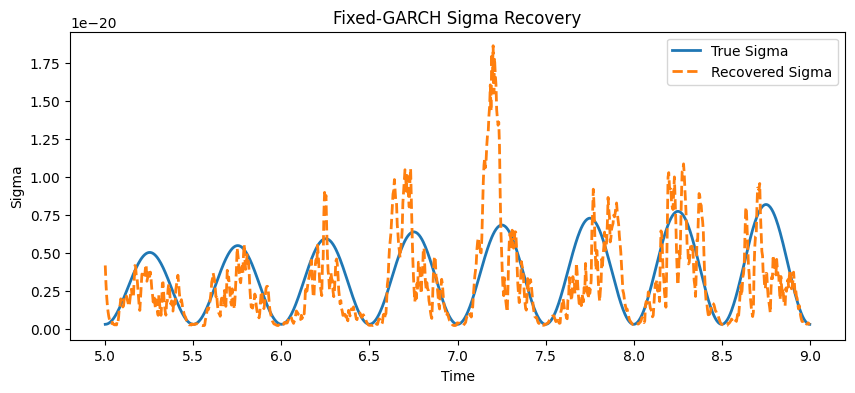


Estimated Parameters

cr = 19.562469985218424 + 0.16920690470973554 - 0.11490508353137585
tc = 7.956880000284283 + 0.02611816408356482 - 0.011450953890113524


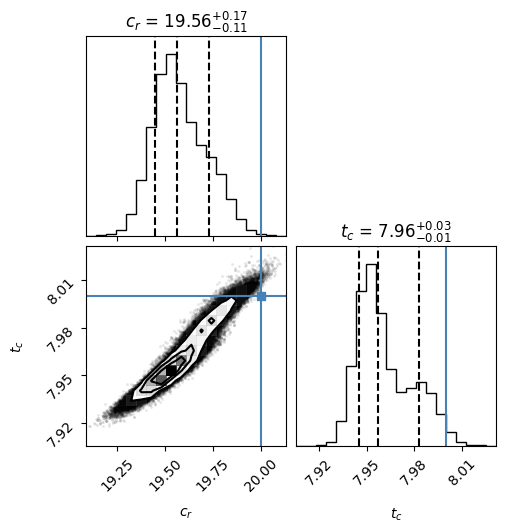

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from arch import arch_model
import emcee
import corner

# =====================================================
# Generate Data
# =====================================================

N = 1000
t = np.linspace(5, 9, N)

A_true = 2e-22
cr_true = 20.0
tc_true = 8.0

# =====================================================
# Chirp Model
# =====================================================

def generate_chirp(t, A, cr, tc, apply_window=True):
    h = np.zeros_like(t)
    valid = (t < tc) & (t > tc - 2.0)
    if not np.any(valid):
        return h
    tau = tc - t[valid]
    phase = -2.0 * cr * (tau + 1e-5)**(-0.25)
    amplitude = A * np.sqrt(cr / (tau + 0.1))
    signal = amplitude * np.sin(phase)
    if apply_window:
        signal *= tukey(len(signal), alpha=0.5)
    h[valid] = signal
    return h

# =====================================================
# Colored Rolling Noise
# =====================================================

sigma_true = 3e-22 * (1 + 3*t*np.sin(2*np.pi*t)**2)
phi = 0.95
white = np.random.normal(0,1,N)
colored = np.zeros(N)
for i in range(1,N):
    colored[i] = phi*colored[i-1] + white[i]
colored /= np.std(colored)
noise = sigma_true * colored

# =====================================================
# High-Amplitude Sine-Gaussian Glitch
# =====================================================

glitch_amp = 5e-21
glitch_t0  = 7.2
glitch_tau = 0.01
glitch_f0  = 120

glitch = (glitch_amp* np.exp(-(t-glitch_t0)**2/(2*glitch_tau**2))* np.sin(2*np.pi*glitch_f0*(t-glitch_t0)))

# =====================================================
# Data
# =====================================================

h_true = generate_chirp(t,A_true,cr_true,tc_true)

data = h_true + noise + glitch

# =====================================================
# Plot Data
# =====================================================

plt.figure(figsize=(10,4))
plt.plot(t,data,label="Data")
plt.plot(t,h_true,lw=2,label="True Signal")
plt.plot(t,glitch,lw=2,label="Injected Glitch")
plt.xlabel("Time")
plt.ylabel("Strain")
plt.legend()
plt.show()

# =====================================================
# Estimate GARCH Parameters Once
# =====================================================

signal_start = tc_true - 2.0
background_mask = t < signal_start
background_data = data[background_mask]

scale = 1e22
background_scaled = background_data * scale
garch = arch_model(background_scaled,mean="Zero",vol="GARCH",p=1,q=1)
result = garch.fit(disp="off")

omega_fixed = result.params["omega"]
alpha_fixed = result.params["alpha[1]"]
beta_fixed  = result.params["beta[1]"]

print("\nFixed GARCH Parameters")
print("omega =", omega_fixed)
print("alpha =", alpha_fixed)
print("beta  =", beta_fixed)

# =====================================================
# GARCH Recursion
# =====================================================

def garch_sigma(residual,omega,alpha,beta):
    r = residual * scale
    N = len(r)
    sigma2 = np.zeros(N)
    sigma2[0] = np.var(r)
    for i in range(1,N):
        sigma2[i] = (omega+ alpha*r[i-1]**2+ beta*sigma2[i-1])
        if sigma2[i] < 1e-12:
            sigma2[i] = 1e-12
    sigma2 /= scale**2
    return np.sqrt(sigma2)

# =====================================================
# Prior
# =====================================================

def log_prior(theta):
    cr, tc = theta
    if (
        18 < cr < 22
        and
        7.5 < tc < 8.5
    ):
        return 0.0
    return -np.inf

# =====================================================
# Fixed-GARCH Likelihood
# =====================================================

def log_likelihood(theta,t,data):
    cr, tc = theta
    model = generate_chirp(t,A_true,cr,tc)
    residual = data - model
    sigma_t = garch_sigma(residual,omega_fixed,alpha_fixed,beta_fixed)
    sigma2 = sigma_t**2
    lnL = -0.5*np.sum(residual**2/sigma2+ np.log(sigma2))
    return lnL

# =====================================================
# Posterior
# =====================================================

def log_probability(theta,t,data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta,t,data)

# =====================================================
# Initial Walkers
# =====================================================

ndim = 2
nwalkers = 64

initial = np.array([20.0,8.0])
pos = (initial+ 1e-4*np.abs(initial)* np.random.randn(nwalkers,ndim))

# =====================================================
# Run MCMC
# =====================================================

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_probability,args=(t,data))

print("\nRunning MCMC...")
sampler.run_mcmc(pos,30000,progress=True)
print("Done")

print("Acceptance Fraction =",np.mean(sampler.acceptance_fraction))

# =====================================================
# Burn-in Removal
# =====================================================

flat_samples = sampler.get_chain(discard=10000,thin=5,flat=True)

# =====================================================
# Sigma Recovery Plot
# =====================================================

best = np.median(flat_samples,axis=0)
cr_fit, tc_fit = best
model_fit = generate_chirp(t,A_true,cr_fit,tc_fit)
residual_fit = data - model_fit
sigma_fit = garch_sigma(residual_fit,omega_fixed,alpha_fixed,beta_fixed)

plt.figure(figsize=(10,4))
plt.plot(t,sigma_true,lw=2,label="True Sigma")
plt.plot(t,sigma_fit,"--",lw=2,label="Recovered Sigma")
plt.xlabel("Time")
plt.ylabel("Sigma")
plt.legend()
plt.title("Fixed-GARCH Sigma Recovery")
plt.show()

# =====================================================
# Parameter Estimates
# =====================================================

cr_mcmc = np.percentile(flat_samples[:,0],[16,50,84])
tc_mcmc = np.percentile(flat_samples[:,1],[16,50,84])

print("\nEstimated Parameters\n")
print("cr =",cr_mcmc[1],"+",cr_mcmc[2]-cr_mcmc[1],"-",cr_mcmc[1]-cr_mcmc[0])
print("tc =",tc_mcmc[1],"+",tc_mcmc[2]-tc_mcmc[1],"-",tc_mcmc[1]-tc_mcmc[0])

# =====================================================
# Corner Plot
# =====================================================

corner.corner(flat_samples,labels=[r"$c_r$",r"$t_c$"],truths=[cr_true,tc_true],show_titles=True,quantiles=[0.16,0.5,0.84],
    title_quantiles=[0.16,0.5,0.84])
plt.show()


__WORK 5 : ARMA-GARCH WITH ROLLING COLOURED NOISE__

1. Generate chirp signal.
2. Generate colored rolling noise.
3. Inject a sine-Gaussian glitch.
4. Construct data.
5. Estimate ARMA(1,1)-GARCH(1,1) parameters from the background region.
6. Fix the estimated ARMA-GARCH parameters.
7. Sample only: (rc, tc)
8. At each MCMC step:
   - Generate chirp.
   - Compute residuals.
   - Compute ARMA innovations.
   - Compute $σ_t$ using fixed GARCH parameters.
   - Evaluate ARMA-GARCH likelihood.
9. Recover posterior distributions.
10. Compare recovered $σ_t$ with true $σ_t$
11. Plots:
    - Data + signal + glitch
    - True vs recovered $σ_t$
    - Corner plot for (rc, tc)

- ARMA  -> handles correlations
- GARCH -> handles changing variance

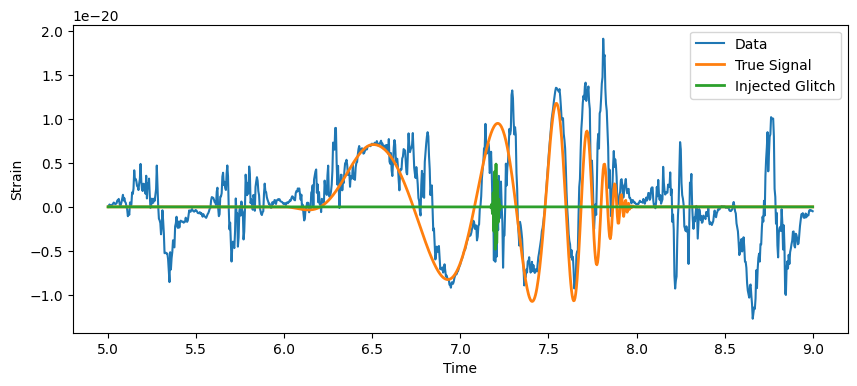


ARMA Parameters
phi = 0.8667692852333355
theta = 0.049359457061033486

GARCH Parameters
omega = 0.9958322163414417
alpha = 0.22845443582759004
beta = 0.7715455640607505

Running MCMC...


100%|█████████████████████████████████████| 30000/30000 [42:26<00:00, 11.78it/s]


Done
Acceptance Fraction = 0.0023067708333333334


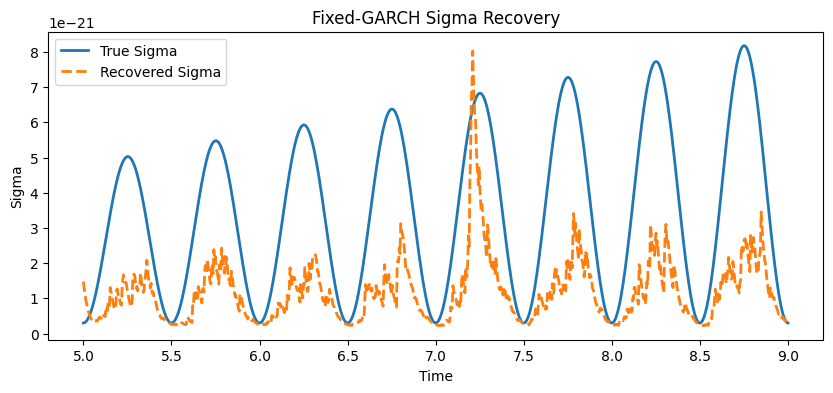


Estimated Parameters

cr = 20.015756244601004 + 5.668194802410653e-09 - 7.032003424001232e-09
tc = 8.000047693114848 + 8.213874025386758e-11 - 1.6827428339638573e-10


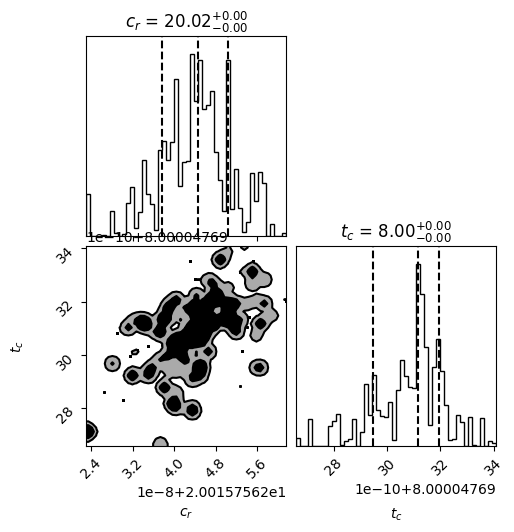

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import emcee
import corner

# =====================================================
# Generate Data
# =====================================================

N = 1000
t = np.linspace(5, 9, N)

A_true = 2e-21
cr_true = 20.0
tc_true = 8.0

# =====================================================
# Chirp Model
# =====================================================

def generate_chirp(t, A, cr, tc, apply_window=True):
    h = np.zeros_like(t)
    valid = (t < tc) & (t > tc - 2.0)
    if not np.any(valid):
        return h
    tau = tc - t[valid]
    phase = -2.0 * cr * (tau + 1e-5)**(-0.25)
    amplitude = A * np.sqrt(cr / (tau + 0.1))
    signal = amplitude * np.sin(phase)
    if apply_window:
        signal *= tukey(len(signal), alpha=0.5)
    h[valid] = signal
    return h

# =====================================================
# Colored Rolling Noise
# =====================================================

sigma_true = 3e-22 * (1 + 3*t*np.sin(2*np.pi*t)**2)
phi = 0.95
white = np.random.normal(0,1,N)
colored = np.zeros(N)
for i in range(1,N):
    colored[i] = phi*colored[i-1] + white[i]
colored /= np.std(colored)
noise = sigma_true * colored

# =====================================================
# High-Amplitude Sine-Gaussian Glitch
# =====================================================

glitch_amp = 5e-21
glitch_t0  = 7.2
glitch_tau = 0.01
glitch_f0  = 120

glitch = (glitch_amp* np.exp(-(t-glitch_t0)**2/(2*glitch_tau**2))* np.sin(2*np.pi*glitch_f0*(t-glitch_t0)))

# =====================================================
# Data
# =====================================================

h_true = generate_chirp(t,A_true,cr_true,tc_true)

data = h_true + noise + glitch

# =====================================================
# Plot Data
# =====================================================

plt.figure(figsize=(10,4))
plt.plot(t,data,label="Data")
plt.plot(t,h_true,lw=2,label="True Signal")
plt.plot(t,glitch,lw=2,label="Injected Glitch")
plt.xlabel("Time")
plt.ylabel("Strain")
plt.legend()
plt.show()

# =====================================================
# Estimate ARMA(1,1)-GARCH(1,1)
# =====================================================

signal_start = tc_true - 2.0
background_mask = t < signal_start
background_data = data[background_mask]

scale = 1e22
background_scaled = background_data * scale

# -----------------------------------------------------
# ARMA(1,1)
# -----------------------------------------------------

arma_model = ARIMA(background_scaled,order=(1,0,1))
arma_result = arma_model.fit()

phi_fixed = arma_result.arparams[0]
theta_fixed = arma_result.maparams[0]
arma_residuals = arma_result.resid

# -----------------------------------------------------
# GARCH(1,1)
# -----------------------------------------------------

garch = arch_model(arma_residuals,mean="Zero",vol="GARCH",p=1,q=1)
result = garch.fit(disp="off")

omega_fixed = result.params["omega"]
alpha_fixed = result.params["alpha[1]"]
beta_fixed  = result.params["beta[1]"]

print("\nARMA Parameters")
print("phi =", phi_fixed)
print("theta =", theta_fixed)

print("\nGARCH Parameters")
print("omega =", omega_fixed)
print("alpha =", alpha_fixed)
print("beta =", beta_fixed)

# =====================================================
# ARMA Innovations
# =====================================================

def arma_innovations(residual, phi, theta):
    r = residual * scale
    N = len(r)
    eps = np.zeros(N)
    for i in range(1, N):
        eps[i] = (r[i]- phi * r[i-1]- theta * eps[i-1])
    return eps

# =====================================================
# GARCH Recursion
# =====================================================

def garch_sigma(eps,omega,alpha,beta):
    r = eps    
    N = len(r)
    sigma2 = np.zeros(N)
    sigma2[0] = np.var(r)
    for i in range(1,N):
        sigma2[i] = (omega+ alpha*r[i-1]**2+ beta*sigma2[i-1])
    return np.sqrt(sigma2) / scale

# =====================================================
# Prior
# =====================================================

def log_prior(theta):
    cr, tc = theta
    if (
        18 < cr < 22
        and
        7.5 < tc < 8.5
    ):
        return 0.0
    return -np.inf

# =====================================================
# Likelihood
# =====================================================

def log_likelihood(theta,t,data):
    cr, tc = theta
    model = generate_chirp(t,A_true,cr,tc)
    residual = data - model
    eps = arma_innovations(residual,phi_fixed,theta_fixed)
    sigma_t = garch_sigma(eps,omega_fixed,alpha_fixed,beta_fixed)
    sigma2 = sigma_t**2
    return -0.5*np.sum(eps**2/sigma2+ np.log(sigma2))

# =====================================================
# Posterior
# =====================================================

def log_probability(theta,t,data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta,t,data)

# =====================================================
# Initial Walkers
# =====================================================

ndim = 2
nwalkers = 64

initial = np.array([20.0,8.0])
pos = (initial+ 1e-4*np.abs(initial)* np.random.randn(nwalkers,ndim))

# =====================================================
# Run MCMC
# =====================================================

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_probability,args=(t,data))

print("\nRunning MCMC...")
sampler.run_mcmc(pos,30000,progress=True)
print("Done")

print("Acceptance Fraction =",np.mean(sampler.acceptance_fraction))

# =====================================================
# Burn-in Removal
# =====================================================

flat_samples = sampler.get_chain(discard=10000,thin=5,flat=True)

# =====================================================
# Sigma Recovery Plot
# =====================================================

best = np.median(flat_samples,axis=0)
cr_fit, tc_fit = best
model_fit = generate_chirp(t,A_true,cr_fit,tc_fit)
residual_fit = data - model_fit
eps_fit = arma_innovations(residual_fit,phi_fixed,theta_fixed)
sigma_fit = garch_sigma(eps_fit,omega_fixed,alpha_fixed,beta_fixed)

plt.figure(figsize=(10,4))
plt.plot(t,sigma_true,lw=2,label="True Sigma")
plt.plot(t,sigma_fit,"--",lw=2,label="Recovered Sigma")
plt.xlabel("Time")
plt.ylabel("Sigma")
plt.legend()
plt.title("Fixed-GARCH Sigma Recovery")
plt.show()

# =====================================================
# Parameter Estimates
# =====================================================

cr_mcmc = np.percentile(flat_samples[:,0],[16,50,84])
tc_mcmc = np.percentile(flat_samples[:,1],[16,50,84])

print("\nEstimated Parameters\n")
print("cr =",cr_mcmc[1],"+",cr_mcmc[2]-cr_mcmc[1],"-",cr_mcmc[1]-cr_mcmc[0])
print("tc =",tc_mcmc[1],"+",tc_mcmc[2]-tc_mcmc[1],"-",tc_mcmc[1]-tc_mcmc[0])

# =====================================================
# Corner Plot
# =====================================================

fig = corner.corner(flat_samples,labels=[r"$c_r$", r"$t_c$"],truths=[cr_true, tc_true],show_titles=True,quantiles=[0.16,0.5,0.84],bins=50,
    smooth=1.0,plot_datapoints=True,fill_contours=True,levels=(0.68,0.95))
plt.show()
